In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")

In [58]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

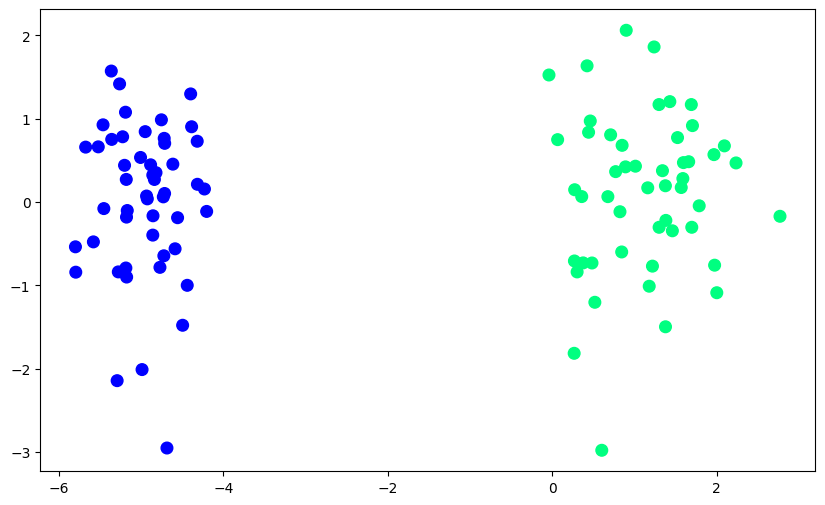

In [59]:
plt.figure(figsize = (10 , 6))
plt.scatter(X[: , 0] , X[: , 1] , c = y , cmap = 'winter' , s = 70)
plt.show()

## Perceptron Function with Step Function

In [61]:
def perceptron_step_function(X , y): 
    # add a bias column 
    X = np.insert(X , 0 , 1 , axis = 1)
    # initialize weights
    weights = np.ones(X.shape[1])
    learning_rate = 0.1
    rows = X.shape[0]
    epochs = 1000 # number of iterations

    for epoch in range(epochs): 
        # choose a row randomly
        index = np.random.randint(low = 0 , high = rows)
        # Find the value of z 
        z = np.dot(X[index] , weights)
        # do the prediction by sending z to a step function  
        y_hat = step_function(z) 
        # update weights
        weights = weights + learning_rate * (y[index] - y_hat) * X[index]
    
    return weights[0] , weights[1 : ] 

In [62]:
def step_function(z): 
    return 1 if z > 0 else 0

In [63]:
X.shape[0]

100

## Perceptron Function with Sigmoid Function

In [64]:
def perceptron_sigmoid_function(X , y): 
    # add a bias column 
    X = np.insert(X , 0 , 1 , axis = 1)
    # initialize weights
    weights = np.ones(X.shape[1])
    learning_rate = 0.1
    rows = X.shape[0]
    epochs = 1000 # number of iterations

    for epoch in range(epochs): 
        # choose a row randomly
        index = np.random.randint(low = 0 , high = rows)
        # Find the value of z 
        z = np.dot(X[index] , weights)
        # do the prediction by sending z to a step function  
        y_hat = sigmoid_function(z) 
        # update weights
        weights = weights + learning_rate * (y[index] - y_hat) * X[index]
    
    return weights[0] , weights[1 : ] 

In [65]:
def sigmoid_function(z): 
    return 1 / (1 + np.exp(-z))

In [66]:
# step functions intercept and coef
intercept_step , coef_step = perceptron_step_function(X , y)

print(intercept_step)
print(coef_step)

1.2000000000000002
[1.1204053  0.40381514]


In [67]:
# sigmoid functions intercept and coef
intercept_sigmoid , coef_sigmoid = perceptron_sigmoid_function(X , y)

In [68]:
print(intercept_sigmoid)
print(coef_sigmoid)

2.601872652183955
[2.34296296 0.18669164]


In [69]:
''' 
Ax + By + c = 0
y = (-A/B)x + (-c/b)
'''
slope_step = - coef_step[0] / coef_step[1]
c_step = -intercept_step / coef_step[1]

In [70]:
x_input_step = np.linspace(-3 , 3 , 100)
y_input_step = slope_step * x_input_step + c_step 

In [71]:
slope_sigmoid = - coef_sigmoid[0] / coef_sigmoid[1]
c_sigmoid = -intercept_sigmoid / coef_sigmoid[1]

In [72]:
x_input_sigmoid = np.linspace(-3 , 3 , 100)
y_input_sigmoid = slope_sigmoid * x_input_sigmoid + c_sigmoid 

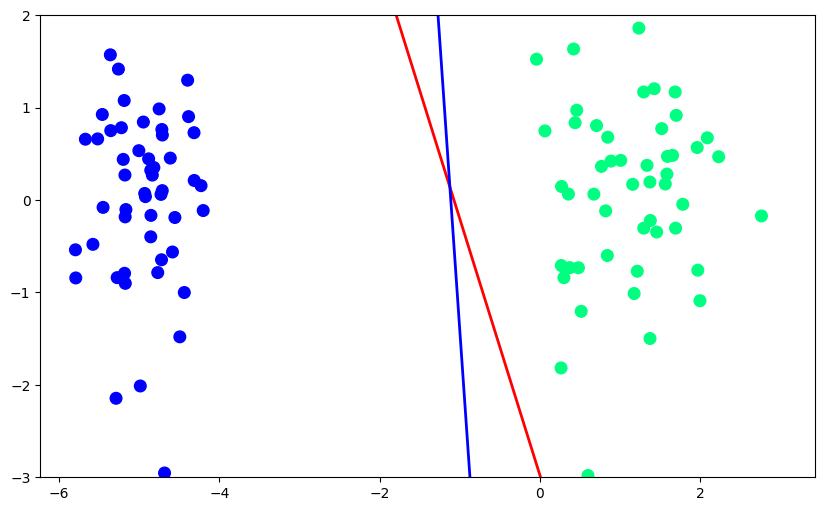

In [73]:
plt.figure(figsize = (10 , 6))
plt.scatter(X[: , 0] , X[: , 1] , c = y , cmap = 'winter' , s = 70)

# plot the step functions line 
plt.plot(x_input_step , y_input_step , color = 'red' , linewidth = 2)

# plot the sigmoid functions line 
plt.plot(x_input_sigmoid , y_input_sigmoid , color = 'blue' , linewidth = 2)


plt.ylim(-3 , 2)
plt.show()